# Neural Network for Cardiac Disease Classification

This notebook applies the Day 2 and Day 3 ideas to the cardiac-disease project. Day 2 defines **how patient features move forward through the network** and how prediction error is measured. Day 3 explains **how the network learns from that error**.

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

df = pd.read_csv(
    "../../data/LLCP2024/processed/brfss_2024_cardiac_clean.csv"
)

In [2]:
X = df.drop(
    columns="cardiac_disease"
)

y = df["cardiac_disease"]

## 1. Protecting the final evaluation

The target is `cardiac_disease`: `0` means the condition was not reported and `1` means it was reported. A stratified split keeps the class proportions similar in each subset.

> The **validation set** guides choices such as the learning rate and stopping point. The **test set** remains untouched until the final model is fixed, giving a more honest estimate of performance on unseen data.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

## 2. Preparing features for the network

Missing numeric values are filled with the median and then standardized so that differences in measurement scale do not dominate learning. Categorical values are filled with their most common category and one-hot encoded, turning them into numeric indicators without inventing an order between categories.

The preprocessor is fitted only on training data to prevent information from the validation or test sets leaking into training. After transformation, each patient is represented by **61 numeric inputs**.

In [4]:
numeric_features = [
    "age",
    "bmi",
    "poor_physical_health_days",
    "poor_mental_health_days",
    "alcohol_days_per_month",
]
categorical_features = [
    "sex",
    "general_health",
    "last_checkup",
    "physical_activity",
    "diabetes_status",
    "stroke_history",
    "kidney_disease",
    "smoking_status",
    "education_level",
    "income_level",
    "employment_status",
    "difficulty_walking",
    "personal_doctor",
    "medical_cost_barrier",
]

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

In [6]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
])

In [7]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "one_hot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype="float32",
        )
    ),
])

In [8]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features,
    ),
])

In [9]:
from sklearn.linear_model import LogisticRegression

baseline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        )
    ),
])

In [10]:
baseline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
X_train_nn, X_val, y_train_nn, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42,
)

In [12]:
from sklearn.base import clone

nn_preprocessor = clone(preprocessor)
X_train_nn_processed = nn_preprocessor.fit_transform(X_train_nn)
X_val_processed = nn_preprocessor.transform(X_val)
X_test_processed = nn_preprocessor.transform(X_test)

In [13]:
print(X_train_nn_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)

(316724, 61)
(45247, 61)
(90493, 61)


## 3. Day 2 — Activations and network design

A stack of layers without activation functions would still behave like one linear model. The activations add the non-linearity needed to learn more complex relationships among patient features.

| Part | Choice | Why it fits this task |
|---|---|---|
| Hidden layers | 64 and 32 neurons with **ReLU** | ReLU keeps positive signals and sets negative ones to zero. It is efficient and lets the network learn non-linear feature combinations. |
| Output layer | 1 neuron with **sigmoid** | This is a binary task, so one value between 0 and 1 is enough. It is the model's probability-like score for `cardiac_disease = 1`. |

> This score should not automatically be described as a patient's clinical risk. That interpretation would require additional probability-calibration and clinical validation work.

In [14]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

tf.keras.utils.set_random_seed(42)

input_dim = X_train_nn_processed.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,081 (23.75 KB)

 Trainable params: 6,081 (23.75 KB)

 Non-trainable params: 0 (0.00 B)

### Measuring prediction error

`binary_crossentropy` matches a binary target and a sigmoid output. It gives a large penalty when the model is confidently wrong and a smaller penalty when its probability-like score agrees with the true class. Training aims to reduce this loss; accuracy and ROC-AUC are tracked to provide additional views of performance.

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
    ],
)

### A forward pass before learning

A forward pass sends one patient's 61 processed features through the two ReLU layers and then the sigmoid output. At this point the weights are **randomly initialized**, so the score is a useful pipeline check but is not expected to be meaningful.

In [16]:
sample = X_val_processed[:1]

prediction_before_training = model.predict(
    sample,
    verbose=0
)[0][0]

print(
    f"Prediction before training: "
    f"{prediction_before_training:.4f}"
)

print(
    f"Actual class: "
    f"{y_val.iloc[0]}"
)

Prediction before training: 0.5494
Actual class: 0


## 4. Day 3 — How the network learns

Each batch repeats the same training loop:

**forward pass → loss calculation → backpropagation → optimizer update**

TensorFlow performs backpropagation automatically: it works backward from the loss and uses gradients and the chain rule to measure how each weight affected the error. Adam then uses those gradients to update the weights. One **epoch** is one complete pass through the training set; a **batch** is the smaller group of patients used for each update.

In [17]:
history = model.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(
        X_val_processed,
        y_val,
    ),
    epochs=20,
    batch_size=256,
    verbose=2,
)

Epoch 1/20


1238/1238 - 2s - 1ms/step - accuracy: 0.9072 - auc: 0.8253 - loss: 0.2478 - val_accuracy: 0.9081 - val_auc: 0.8380 - val_loss: 0.2410


Epoch 2/20


1238/1238 - 1s - 936us/step - accuracy: 0.9085 - auc: 0.8393 - loss: 0.2403 - val_accuracy: 0.9087 - val_auc: 0.8389 - val_loss: 0.2404


Epoch 3/20


1238/1238 - 1s - 939us/step - accuracy: 0.9086 - auc: 0.8407 - loss: 0.2396 - val_accuracy: 0.9085 - val_auc: 0.8388 - val_loss: 0.2405


Epoch 4/20


1238/1238 - 1s - 930us/step - accuracy: 0.9088 - auc: 0.8415 - loss: 0.2391 - val_accuracy: 0.9084 - val_auc: 0.8387 - val_loss: 0.2406


Epoch 5/20


1238/1238 - 1s - 945us/step - accuracy: 0.9090 - auc: 0.8422 - loss: 0.2387 - val_accuracy: 0.9085 - val_auc: 0.8388 - val_loss: 0.2407


Epoch 6/20


1238/1238 - 1s - 908us/step - accuracy: 0.9092 - auc: 0.8428 - loss: 0.2383 - val_accuracy: 0.9085 - val_auc: 0.8386 - val_loss: 0.2407


Epoch 7/20


1238/1238 - 1s - 938us/step - accuracy: 0.9093 - auc: 0.8436 - loss: 0.2379 - val_accuracy: 0.9081 - val_auc: 0.8384 - val_loss: 0.2409


Epoch 8/20


1238/1238 - 1s - 933us/step - accuracy: 0.9093 - auc: 0.8441 - loss: 0.2376 - val_accuracy: 0.9084 - val_auc: 0.8383 - val_loss: 0.2410


Epoch 9/20


1238/1238 - 1s - 1ms/step - accuracy: 0.9095 - auc: 0.8446 - loss: 0.2372 - val_accuracy: 0.9083 - val_auc: 0.8384 - val_loss: 0.2411


Epoch 10/20


1238/1238 - 1s - 923us/step - accuracy: 0.9096 - auc: 0.8451 - loss: 0.2370 - val_accuracy: 0.9085 - val_auc: 0.8382 - val_loss: 0.2412


Epoch 11/20


1238/1238 - 1s - 945us/step - accuracy: 0.9097 - auc: 0.8456 - loss: 0.2367 - val_accuracy: 0.9081 - val_auc: 0.8380 - val_loss: 0.2414


Epoch 12/20


1238/1238 - 1s - 935us/step - accuracy: 0.9099 - auc: 0.8461 - loss: 0.2364 - val_accuracy: 0.9083 - val_auc: 0.8377 - val_loss: 0.2416


Epoch 13/20


1238/1238 - 1s - 938us/step - accuracy: 0.9099 - auc: 0.8465 - loss: 0.2361 - val_accuracy: 0.9084 - val_auc: 0.8372 - val_loss: 0.2419


Epoch 14/20


1238/1238 - 1s - 936us/step - accuracy: 0.9101 - auc: 0.8470 - loss: 0.2359 - val_accuracy: 0.9085 - val_auc: 0.8368 - val_loss: 0.2420


Epoch 15/20


1238/1238 - 1s - 935us/step - accuracy: 0.9101 - auc: 0.8474 - loss: 0.2356 - val_accuracy: 0.9084 - val_auc: 0.8365 - val_loss: 0.2422


Epoch 16/20


1238/1238 - 1s - 932us/step - accuracy: 0.9101 - auc: 0.8477 - loss: 0.2354 - val_accuracy: 0.9085 - val_auc: 0.8361 - val_loss: 0.2425


Epoch 17/20


1238/1238 - 1s - 954us/step - accuracy: 0.9103 - auc: 0.8482 - loss: 0.2351 - val_accuracy: 0.9080 - val_auc: 0.8356 - val_loss: 0.2428


Epoch 18/20


1238/1238 - 1s - 937us/step - accuracy: 0.9105 - auc: 0.8485 - loss: 0.2348 - val_accuracy: 0.9077 - val_auc: 0.8350 - val_loss: 0.2432


Epoch 19/20


1238/1238 - 1s - 948us/step - accuracy: 0.9105 - auc: 0.8489 - loss: 0.2346 - val_accuracy: 0.9077 - val_auc: 0.8348 - val_loss: 0.2434


Epoch 20/20


1238/1238 - 1s - 941us/step - accuracy: 0.9106 - auc: 0.8492 - loss: 0.2344 - val_accuracy: 0.9075 - val_auc: 0.8343 - val_loss: 0.2437


### The same patient after training

The second score is produced by **learned weights**, not the initial random weights. For this class-0 patient, the score moves from `0.5494` before training to `0.0478` afterward. This shows how training changed the forward pass, but one correctly scored example is not evidence of overall model quality; the validation curves and evaluation across many patients are more informative.

In [18]:
prediction_after_training = model.predict(
    sample,
    verbose=0
)[0][0]

print(
    f"Before training: "
    f"{prediction_before_training:.4f}"
)

print(
    f"After training: "
    f"{prediction_after_training:.4f}"
)

print(
    f"Actual class: "
    f"{y_val.iloc[0]}"
)

Before training: 0.5494
After training: 0.0478
Actual class: 0


### Reading the first learning curves

Training loss continues to fall, but validation loss reaches its minimum near epoch 2 and then gradually rises. Training ROC-AUC also improves while validation ROC-AUC peaks early and later declines. Together, these curves show that longer training is fitting the training data more closely without improving unseen validation data—an early sign of overfitting. This motivates early stopping below.

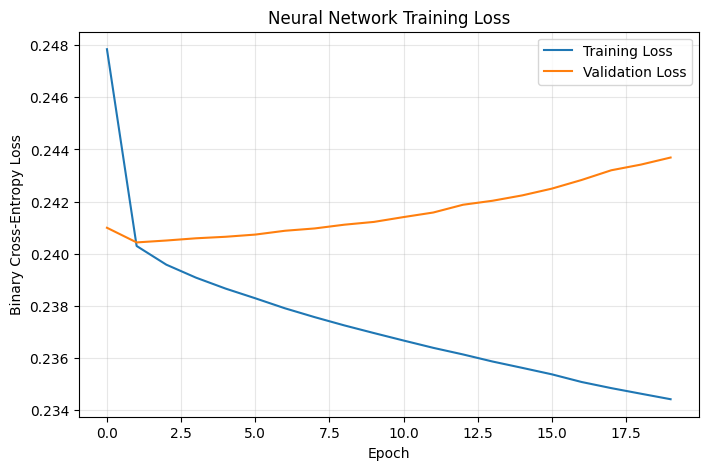

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Neural Network Training Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

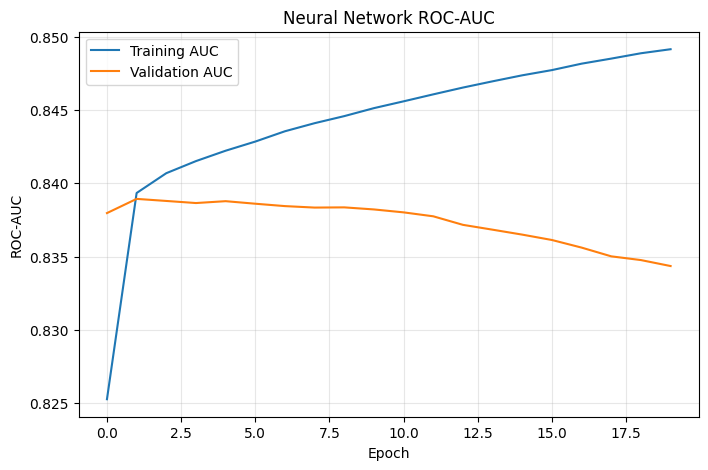

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["auc"],
    label="Training AUC"
)

plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Neural Network ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

In [22]:
def create_model(learning_rate=0.001):
    model = Sequential([
        Input(
            shape=(
                X_train_nn_processed.shape[1],
            )
        ),
        Dense(
            64,
            activation="relu"
        ),
        Dense(
            32,
            activation="relu"
        ),
        Dense(
            1,
            activation="sigmoid"
        ),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(
                name="auc"
            ),
        ],
    )

    return model

## 5. Class imbalance and learning-rate experiment

Class `1` is much less common than class `0`, so ordinary training could favor the majority class. The computed class weights make errors on the minority class count more heavily during training. This encourages the model to detect more class-1 cases, although it can also create more false positives.

In [23]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_nn)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_nn,
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(0): np.float64(0.5516148358691412), np.int64(1): np.float64(5.34356863274396)}


In [24]:
learning_rates = {
    "1e-5": 0.00001,
    "1e-3": 0.001,
    "1e-1": 0.1,
}

histories = {}

for name, lr in learning_rates.items():

    print(
        f"\nTraining: {name} "
        f"(learning_rate={lr})"
    )

    tf.keras.utils.set_random_seed(42)

    experiment_model = create_model(lr)

    histories[name] = experiment_model.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(
        X_val_processed,
        y_val,
    ),
    epochs=10,
    batch_size=256,
    class_weight=class_weights,
    verbose=0,
)


Training: 1e-5 (learning_rate=1e-05)



Training: 1e-3 (learning_rate=0.001)



Training: 1e-1 (learning_rate=0.1)


### What the learning-rate plot actually shows

The learning rate controls the size of Adam's updates, but its effect should be judged from the curves rather than from preset labels:

- `1e-5` learns slowly and steadily.
- `1e-3` reaches a very low validation loss quickly, then begins to worsen.
- `1e-1` behaves less consistently and is more unstable.

Therefore, `0.001` is selected because it reaches the lowest validation loss quickly. Early stopping is important here: it keeps the weights from the best validation epoch instead of keeping later, less generalizable updates.

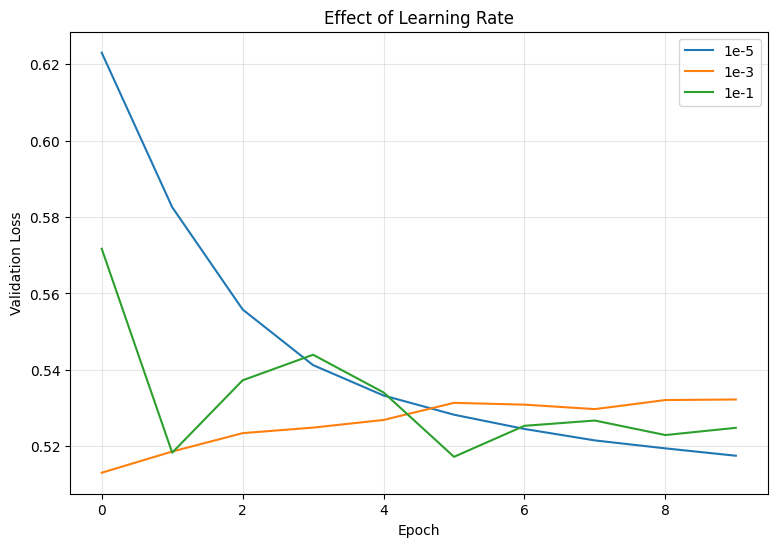

In [25]:
plt.figure(figsize=(9, 6))

for name, lr_history in histories.items():
    plt.plot(
        lr_history.history["val_loss"],
        label=name,
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [26]:
tf.keras.utils.set_random_seed(42)

final_nn = create_model(
    learning_rate=0.001
)

In [27]:
history = final_nn.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(
        X_val_processed,
        y_val,
    ),
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[
        early_stopping
    ],
    verbose=2,
)

Epoch 1/50


1238/1238 - 2s - 1ms/step - accuracy: 0.7255 - auc: 0.8322 - loss: 0.5019 - val_accuracy: 0.7158 - val_auc: 0.8377 - val_loss: 0.5131


Epoch 2/50


1238/1238 - 1s - 931us/step - accuracy: 0.7266 - auc: 0.8400 - loss: 0.4916 - val_accuracy: 0.7094 - val_auc: 0.8380 - val_loss: 0.5186


Epoch 3/50


1238/1238 - 1s - 940us/step - accuracy: 0.7268 - auc: 0.8413 - loss: 0.4897 - val_accuracy: 0.7062 - val_auc: 0.8383 - val_loss: 0.5234


Epoch 4/50


1238/1238 - 1s - 937us/step - accuracy: 0.7273 - auc: 0.8422 - loss: 0.4884 - val_accuracy: 0.7051 - val_auc: 0.8381 - val_loss: 0.5249


## 6. Final evaluation on untouched test data

Only after the architecture and training choices are complete is the test set used. ROC-AUC measures how well the model ranks class-1 cases above class-0 cases across thresholds, while the classification report shows behavior at the chosen `0.5` threshold.

In [28]:
test_loss, test_accuracy, test_auc = final_nn.evaluate(
    X_test_processed,
    y_test,
    verbose=0,
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")

Test Loss: 0.5100
Test Accuracy: 0.7172
Test ROC-AUC: 0.8393


In [29]:
y_prob_nn = final_nn.predict(
    X_test_processed,
    verbose=0
).ravel()

y_pred_nn = (
    y_prob_nn >= 0.5
).astype(int)

In [30]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

print(
    classification_report(
        y_test,
        y_pred_nn
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_nn
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_nn
    )
)

              precision    recall  f1-score   support

           0       0.97      0.71      0.82     82025
           1       0.22      0.82      0.35      8468

    accuracy                           0.72     90493
   macro avg       0.60      0.76      0.59     90493
weighted avg       0.90      0.72      0.78     90493

[[57965 24060]
 [ 1530  6938]]
ROC-AUC: 0.8392502134719633


### Result and connection to the project

The final model achieves **0.839 test ROC-AUC** and **71.7% test accuracy**. At the `0.5` threshold it recalls **82% of class 1**, but precision for class 1 is **22%**, so many flagged cases are false positives. This trade-off is consistent with giving the minority class more weight; it should be considered when choosing a decision threshold for the project's goal.

**In short:** Day 2 defined how the network transforms patient features into a prediction and measures error, while Day 3 showed how it learns from that error through backpropagation and optimization.